# Setup

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import pypsa
from matplotlib.lines import Line2D
from mineral_analysis_lib import (
    all_mineral_data,
    all_minerals,
    build_capacity_bounds_df,
    build_supply_deficit_table,
    compute_mineral_demand_network,
    compute_mineral_demand_scenarios,
    compute_mineral_supply,
    minerals_color_map,
    plot_comparison_barh,
    plot_mineral_reserve_shares,
    plot_mineral_scenario_comparison,
    plot_mineral_supply_demand,
    plot_mineral_to_tech_sankey,
    plot_stacked_capacity,
    plot_system_cost_compare,
    rare_earths,
    rename_techs_balances,
    stacked_barh_signed,
)


In [3]:
# set matplotlib design

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

## Load data

### Load networks

In [4]:
# load networks
base_2h_irena_phs = {
    "name": "Base",
    "type": "build_new/cluster",
    "folder": "eu-overnight/base_2h_new_irenastat_phs",
    "year": 2050,
    "clusters": 45,
}
low_wind = {
    "name": "Low wind",
    "type": "build_new/cluster",
    "folder": "eu-overnight/ccl_low_wind",
    "year": 2050,
    "clusters": 45,
}
low_offwind = {
    "name": "Low offshore wind",
    "type": "build_new/cluster",
    "folder": "eu-overnight/ccl_low_offwind",
    "year": 2050,
    "clusters": 45,
}
high_nuclear = {
    "name": "High nuclear",
    "type": "build_new/cluster",
    "folder": "eu-overnight/ccl_high_nuclear",
    "year": 2050,
    "clusters": 45,
}

scenarios = [low_wind, high_nuclear, low_offwind, base_2h_irena_phs]

n = {
    s["name"]: pypsa.Network(
        f"../{s['type']}/{s['folder']}/networks/base_s_{s['clusters']}___{s['year']}.nc"
    )
    for s in scenarios
}
# n_mga = {s['name']: pypsa.Network(f'../{s['type']}/{s['folder']}/{s['name']}.nc') for s in mga_scenarios}
stats = {s["name"]: n[s["name"]].statistics for s in scenarios}

sample_base_2h_irena_phs = "Base"

sample_low_wind = "Low wind"
sample_low_offwind = "Low offshore wind"
sample_high_nuclear = "High nuclear"

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


### Load mineral intensities, tech scenarios, mineral allocation data

In [5]:
mineral_alloc_factors = {
    "GDP share": 0.213,
    "Per capita share": 0.068,
    "Per capita share corrected for energy use": 0.046,
}

mineral_intensities = pd.read_csv("data/mineral_intensity_combined.csv")

tech_scenarios = pd.read_csv("data/tech_market_shares.csv")

# mineral_alloc = pd.read_csv("data/mineral_alloc.csv")

mineral_avail = pd.read_csv("data/mineral_availability.csv")
mineral_avail["Value (Mt)"] = mineral_avail["Value (kt)"] / 1000

non_energy_demand = pd.read_csv("data/non_energy_demand.csv")
# non_energy_demand["Value entso-e (Mt)"] = non_energy_demand["Value entso-e (kt)"]/1000
# non_energy_demand = non_energy_demand.set_index("Mineral")
non_energy_demand["GDP-adjusted value entso-e (Mt)"] = (
    non_energy_demand["Value global (kt)"]
    * mineral_alloc_factors["GDP share"]
    / 1000
)

grid_demand = pd.read_csv("data/grid_demand.csv")
grid_demand["GDP-adjusted value entso-e (Mt)"] = (
    grid_demand["Value global (kt)"] * mineral_alloc_factors["GDP share"] / 1000
)

# per-mineral demand/availability specs (data/mineral_specs.json)
mineral_specs = json.load(open("data/mineral_specs.json"))


# Methodology

## EV calculation

<Axes: >

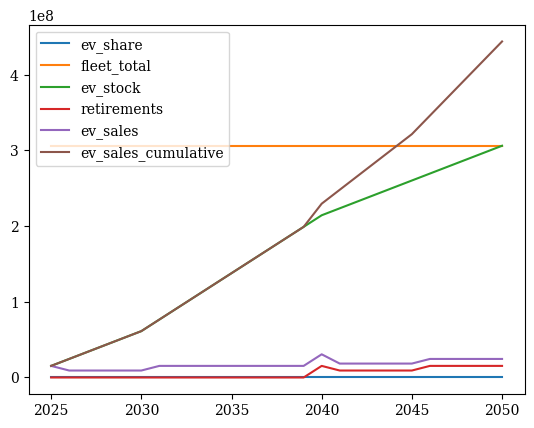

In [6]:
from mineral_analysis_lib import get_total_EVs

# EV share pathway from config (can be replaced by reading YAML)
land_transport_electric_share = {
    2020: 0.0,
    2025: 0.05,
    2030: 0.20,
    2035: 0.45,
    2040: 0.70,
    2045: 0.85,
    2050: 1.0,
}

results_ev_turnover, total_ev_sold = get_total_EVs(2025, 2050, 15, land_transport_electric_share)
results_ev_turnover.plot()

# Analysis

## Numbers for thesis

### Capacities

In [7]:
# total power generation capacity
elec_carriers = [
    "AC",
    "DC",
    "Battery Storage",
    "home battery",
    "low voltage",
    "EV battery",
    "battery",
]
optimal_capacity_GW = (
    n[sample_base_2h_irena_phs].statistics.optimal_capacity(
        nice_names=False, bus_carrier=elec_carriers
    )
    / 1000
)
component = optimal_capacity_GW.index.get_level_values(0).astype(str).str.lower()
carrier = optimal_capacity_GW.index.get_level_values(1).astype(str).str.lower()

component_mask = component.isin(["generator", "link"])
generation_carrier_mask = carrier.str.contains(
    r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
)

base_cap_df = optimal_capacity_GW[component_mask & generation_carrier_mask]
base_cap_df.sum()

np.float64(4501.503454259999)

In [8]:
# nuclear scenario capacity
optimal_capacity_GW = (
    n[sample_high_nuclear].statistics.optimal_capacity(
        nice_names=False, bus_carrier=elec_carriers
    )
    / 1000
)
component = optimal_capacity_GW.index.get_level_values(0).astype(str).str.lower()
carrier = optimal_capacity_GW.index.get_level_values(1).astype(str).str.lower()

component_mask = component.isin(["generator", "link"])
generation_carrier_mask = carrier.str.contains(
    r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
)

nuc_cap_df = optimal_capacity_GW[component_mask & generation_carrier_mask]
base_cap_df.sum() - nuc_cap_df.sum()

np.float64(350.71677116999854)

In [9]:
# low wind scenario capacity
optimal_capacity_GW = (
    n[sample_low_wind].statistics.optimal_capacity(
        nice_names=False, bus_carrier=elec_carriers
    )
    / 1000
)
component = optimal_capacity_GW.index.get_level_values(0).astype(str).str.lower()
carrier = optimal_capacity_GW.index.get_level_values(1).astype(str).str.lower()

component_mask = component.isin(["generator", "link"])
generation_carrier_mask = carrier.str.contains(
    r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
)

low_wind_cap_df = optimal_capacity_GW[component_mask & generation_carrier_mask]

In [10]:
# solar capacity base scenario
solar_carriers = ["solar", "solar rooftop", "solar-hsat"]
cap_solar_base = base_cap_df[
    base_cap_df.index.get_level_values("carrier").isin(solar_carriers)
]
cap_solar_base.sum()

np.float64(2777.4568865)

In [11]:
# solar capacity low wind scenario
solar_carriers = ["solar", "solar rooftop", "solar-hsat"]
cap_solar_low_wind = low_wind_cap_df[
    low_wind_cap_df.index.get_level_values("carrier").isin(solar_carriers)
]
print(cap_solar_low_wind.sum())
print(cap_solar_low_wind.sum() / cap_solar_base.sum())

6389.759478380001
2.300579177101837


### Costs

In [12]:
def expanded_system_cost(k):
    print(k)
    capex = n[k].statistics.expanded_capex(nice_names=False)
    opex = n[k].statistics.opex(nice_names=False)

    sc = capex.add(opex, fill_value=0)

    return sc.sum()


base_cost = expanded_system_cost(sample_base_2h_irena_phs)
low_offwind_cost = expanded_system_cost(sample_low_offwind)
low_wind_cost = expanded_system_cost(sample_low_wind)
high_nuc_cost = expanded_system_cost(sample_high_nuclear)

print("base scenario cost", base_cost)
print("low offshore wind cost", low_offwind_cost)
print("low wind cost", low_wind_cost)
print("high nuclear", high_nuc_cost)

print("pct change low offwind", 100 * (low_offwind_cost - base_cost) / base_cost)
print("pct change low wind", 100 * (low_wind_cost - base_cost) / base_cost)
print("pct change high nuclear", 100 * (high_nuc_cost - base_cost) / base_cost)

Base
Low offshore wind
Low wind
High nuclear
base scenario cost 729056875209.4932
low offshore wind cost 735038207373.5808
low wind cost 858360722165.7162
high nuclear 790099349072.5977
pct change low offwind 0.8204205141565837
pct change low wind 17.735769506194945
pct change high nuclear 8.372799974702117


### Mineral supply comparison

(in base scenario) Cobalt uses [xx] more than GDP-allocated supply, nickel [xx%], graphite [xx%] and manganese [xx%]

In [13]:
n

{'Low wind': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 423
  - Carrier: 77
  - Generator: 560
  - GlobalConstraint: 2
  - Line: 90
  - Link: 1160
  - Load: 502
  - StorageUnit: 67
  - Store: 168
  - SubNetwork: 3
 Snapshots: 4380,
 'High nuclear': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 423
  - Carrier: 77
  - Generator: 560
  - GlobalConstraint: 2
  - Line: 90
  - Link: 1160
  - Load: 502
  - StorageUnit: 67
  - Store: 168
  - SubNetwork: 3
 Snapshots: 4380,
 'Low offshore wind': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 423
  - Carrier: 77
  - Generator: 560
  - GlobalConstraint: 2
  - Line: 90
  - Link: 1160
  - Load: 502
  - StorageUnit: 67
  - Store: 168
  - SubNetwork: 3
 Snapshots: 4380,
 'Base': PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 423
  - Carrier: 77
  - Generator: 560
  - GlobalConstraint: 2


In [14]:
# Data frames passed explicitly to all_mineral_data (no hidden module-level state)
mineral_data_kwargs = dict(
    mineral_intensities=mineral_intensities,
    tech_scenarios=tech_scenarios,
    non_energy_demand=non_energy_demand,
    grid_demand=grid_demand,
    mineral_avail=mineral_avail,
    non_energy_col="GDP-adjusted value entso-e (Mt)",
)

base_scenario_results = all_mineral_data(
    n[sample_base_2h_irena_phs], "Market share current", mineral_specs,
    **mineral_data_kwargs,
)
base_scenario_results

network_scenarios = [
    sample_base_2h_irena_phs,
    sample_low_wind,
    sample_low_offwind,
    sample_high_nuclear,
]
market_scenarios = [
    "EV battery Na-ion",
    "EV battery NMC-811",
    "EV battery LFP",
    "Thin-film solar",
    "Stationary battery vanadium-flow",
    "EV motor induction",
]


results_by_scenario = {}

for network in network_scenarios:
    results = all_mineral_data(
        n[network], "Market share current", mineral_specs, **mineral_data_kwargs
    )
    results_by_scenario[network] = results

for scenario in market_scenarios:
    results = all_mineral_data(
        n[sample_base_2h_irena_phs], scenario, mineral_specs, **mineral_data_kwargs
    )
    results_by_scenario[scenario] = results

In [15]:
results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]

{'Total demand': np.float64(5.165909453463945),
 'Total demand energy': np.float64(4.193801785518945),
 'tech demand': carrier_renamed
 Battery Storage       2.064323e-01
 Combined-Cycle Gas    2.807426e-04
 EV battery            3.975521e+00
 EV motor              6.715164e-03
 H2 Electrolysis       3.407446e-03
 Offshore wind         0.000000e+00
 Onshore Wind          0.000000e+00
 Solar                 0.000000e+00
 heat pump             1.445256e-03
 nuclear               5.777590e-10
 solar rooftop         0.000000e+00
 dtype: float64,
 'dnea': 0.972107667945,
 'grid demand': 0.0,
 'avail': 89    8.61333
 Name: Value (Mt), dtype: float64}

In [16]:
## base scenario
# Cobalt use is 2.8 times higher than GDP-allocated supply, nickel 1.05 times,
# graphite 2.05 times, manganese 2.2 times and vanadium 1.8 times

battery_metals = [
    "Cobalt",
    "Nickel",
    "Graphite (natural and synthetic)",
    "Manganese",
    "Vanadium",
]
for metal in battery_metals:
    print(metal)
    total_demand = results_by_scenario[sample_base_2h_irena_phs][metal]["Total demand"]
    total_avail = results_by_scenario[sample_base_2h_irena_phs][metal]["avail"].values[
        0
    ]
    gdp_avail = total_avail * mineral_alloc_factors["GDP share"]
    # print(cobalt_total_demand)
    # print(cobalt_total_avail)
    # print(cobalt_gdp_avail)
    print(f"Metal demand/GDP avail for {metal}", total_demand / gdp_avail)
    print(
        f"Pct increase from GDP availability for {metal}",
        100 * (total_demand - gdp_avail) / gdp_avail,
    )
    print("\n")

# print(results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]["Total demand"])
# print(results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]["avail"].values[0])

Cobalt
Metal demand/GDP avail for Cobalt 2.8157630889977106
Pct increase from GDP availability for Cobalt 181.57630889977108


Nickel
Metal demand/GDP avail for Nickel 1.0514675244640503
Pct increase from GDP availability for Nickel 5.146752446405031


Graphite (natural and synthetic)
Metal demand/GDP avail for Graphite (natural and synthetic) 2.0480348843972074
Pct increase from GDP availability for Graphite (natural and synthetic) 104.80348843972072


Manganese
Metal demand/GDP avail for Manganese 2.194641735345273
Pct increase from GDP availability for Manganese 119.46417353452732


Vanadium
Metal demand/GDP avail for Vanadium 1.8031759310169513
Pct increase from GDP availability for Vanadium 80.31759310169512




In [17]:
for metal_info in mineral_specs:
    metal_name = metal_info["mineral"]
    use_by_tech = results_by_scenario[sample_base_2h_irena_phs][metal_name][
        "tech demand"
    ]
    total_energy_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name][
        "tech demand"
    ].sum()
    total_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name][
        "Total demand"
    ]
    print(
        f"Prop of energy demand for {metal_name}:",
        100 * use_by_tech.loc["EV battery"] / total_energy_demand,
    )
    print(
        f"Prop of all demand for {metal_name}:",
        100 * use_by_tech.loc["EV battery"] / total_demand,
    )
    print("\n")
    # print(use_by_tech)

Prop of energy demand for Aluminium: 53.56847931688674
Prop of all demand for Aluminium: 5.223587625068266


Prop of energy demand for Cobalt: 94.79515513245572
Prop of all demand for Cobalt: 76.95684456615163


Prop of energy demand for Copper: 58.70526996144961
Prop of all demand for Copper: 13.303334086232526


Prop of energy demand for Gallium: 81.66300437961898
Prop of all demand for Gallium: 6.243730031570292


Prop of energy demand for Germanium: 0.014115642663755755
Prop of all demand for Germanium: 0.0005124611680100114


Prop of energy demand for Graphite (natural and synthetic): 88.50131189845158
Prop of all demand for Graphite (natural and synthetic): 28.77822766676516


Prop of energy demand for Iridium: 0.03724758136082781
Prop of all demand for Iridium: 0.000565671432638381


Prop of energy demand for Lithium: 88.88889224874339
Prop of all demand for Lithium: 67.67393509387747


Prop of energy demand for Manganese: 73.88801167806629
Prop of all demand for Manganese: 1.62

In [18]:
for metal_info in mineral_specs:
    metal_name = metal_info["mineral"]
    use_by_tech = results_by_scenario[sample_base_2h_irena_phs][metal_name][
        "tech demand"
    ]
    total_energy_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name][
        "tech demand"
    ].sum()
    total_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name][
        "Total demand"
    ]
    print(
        f"Prop of energy demand for {metal_name}:",
        100 * use_by_tech.loc["EV motor"] / total_energy_demand,
    )
    print(
        f"Prop of all demand for {metal_name}:",
        100 * use_by_tech.loc["EV motor"] / total_demand,
    )
    print("\n")

Prop of energy demand for Aluminium: 14.505511801491922
Prop of all demand for Aluminium: 1.4144663598406306


Prop of energy demand for Cobalt: 0.16012115600500487
Prop of all demand for Cobalt: 0.12998996517503203


Prop of energy demand for Copper: 13.724142401235454
Prop of all demand for Copper: 3.1100589696727177


Prop of energy demand for Gallium: 0.0
Prop of all demand for Gallium: 0.0


Prop of energy demand for Germanium: 0.0
Prop of all demand for Germanium: 0.0


Prop of energy demand for Graphite (natural and synthetic): 0.07176306718134061
Prop of all demand for Graphite (natural and synthetic): 0.02333540420033159


Prop of energy demand for Iridium: 0.0
Prop of all demand for Iridium: 0.0


Prop of energy demand for Lithium: 1.1997659887010536e-05
Prop of all demand for Lithium: 9.13419929005186e-06


Prop of energy demand for Manganese: 7.84594618084854
Prop of all demand for Manganese: 0.17237893447421884


Prop of energy demand for Nickel: 10.889859031531449
Prop of

In [19]:
# Sub-technologies can help to alleviate bottlenecks on certain battery metals.
# Na-ion and LFP batteries both bring cobalt below allocated supply, decreasing demand by [xx%] and [xx%] respectively.
# LFP battery decreases nickel demand by [xx%], while Na-ion battery decreases lithium demand by [xx%].

# cobalt
total_cobalt_base = results_by_scenario[sample_base_2h_irena_phs]["Cobalt"][
    "Total demand"
]

total_cobalt_lfp = results_by_scenario["EV battery LFP"]["Cobalt"]["Total demand"]
print(100 * (total_cobalt_base - total_cobalt_lfp) / total_cobalt_base)

total_cobalt_na = results_by_scenario["EV battery Na-ion"]["Cobalt"]["Total demand"]
print(100 * (total_cobalt_base - total_cobalt_na) / total_cobalt_base)

# nickel
total_nickel_base = results_by_scenario[sample_base_2h_irena_phs]["Nickel"][
    "Total demand"
]

total_nickel_lfp = results_by_scenario["EV battery LFP"]["Nickel"]["Total demand"]
print(
    "pct decrease in nickel from LFP:",
    100 * (total_nickel_base - total_nickel_lfp) / total_nickel_base,
)

# lithium
total_lithium_base = results_by_scenario[sample_base_2h_irena_phs]["Lithium"][
    "Total demand"
]

total_lithium_na = results_by_scenario["EV battery Na-ion"]["Lithium"]["Total demand"]
print(
    "pct decrease in lithium from SiB:",
    100 * (total_lithium_base - total_lithium_na) / total_lithium_base,
)

# total_cobalt_na = results_by_scenario["EV battery Na-ion"]["Cobalt"]["Total demand"]
# print(100*(total_cobalt_base-total_cobalt_na)/total_cobalt_base)


# results_by_scenario["EV battery LFP"]

76.41881890334722
71.81099113531602
pct decrease in nickel from LFP: 21.974565643113333
pct decrease in lithium from SiB: 67.55267329449033


In [20]:
# The low wind scenario increases battery metal use compared to the base scenario due to the system’s increased reliance on batteries for stationary storage.
# There is therefore a [xx%] increase in cobalt use, [xx%] increase in graphite use, [xx%] increase in nickel use, and [xx%] increase in manganese use.

# cobalt
total_cobalt_low_wind = results_by_scenario[sample_low_wind]["Cobalt"]["Total demand"]
print(
    "pct change cobalt from low wind:",
    100 * (total_cobalt_low_wind - total_cobalt_base) / total_cobalt_base,
)

# graphite
total_graphite_base = results_by_scenario[sample_base_2h_irena_phs][
    "Graphite (natural and synthetic)"
]["Total demand"]

total_graphite_low_wind = results_by_scenario[sample_low_wind][
    "Graphite (natural and synthetic)"
]["Total demand"]
print(
    "pct decrease in graphite from low wind:",
    100 * (total_graphite_low_wind - total_graphite_base) / total_graphite_base,
)

# nickel
total_nickel_base = results_by_scenario[sample_base_2h_irena_phs]["Nickel"][
    "Total demand"
]

total_nickel_low_wind = results_by_scenario[sample_low_wind]["Nickel"]["Total demand"]
print(
    "pct decrease in nickel from low wind:",
    100 * (total_nickel_low_wind - total_nickel_base) / total_nickel_base,
)

# lithium
total_lithium_base = results_by_scenario[sample_base_2h_irena_phs]["Lithium"][
    "Total demand"
]

total_lithium_low_wind = results_by_scenario[sample_low_wind]["Lithium"]["Total demand"]
print(
    "pct decrease in lithium from low wind:",
    100 * (total_lithium_low_wind - total_lithium_base) / total_lithium_base,
)

pct change cobalt from low wind: 7.527681969955752
pct decrease in graphite from low wind: 6.895866423854833
pct decrease in nickel from low wind: 2.6798963662348925
pct decrease in lithium from low wind: 15.872194667484399


In [21]:
# The thin-film solar scenario increases gallium demand by [xx%] compared to the base scenario
total_gallium_base = results_by_scenario[sample_base_2h_irena_phs]["Gallium"][
    "Total demand"
]

total_gallium_thinfilm = results_by_scenario["Thin-film solar"]["Gallium"][
    "Total demand"
]
print(
    "pct change gallium from thin-film:",
    100 * (total_gallium_thinfilm - total_gallium_base) / total_gallium_base,
)

# The thin-film solar scenario increases gallium demand by [xx%] compared to the base scenario
total_copper_base = results_by_scenario[sample_base_2h_irena_phs]["Copper"][
    "Total demand"
]

total_copper_thinfilm = results_by_scenario["Thin-film solar"]["Copper"]["Total demand"]
print(
    "pct change gallium from thin-film:",
    100 * (total_copper_thinfilm - total_copper_base) / total_copper_base,
)

pct change gallium from thin-film: 17.484104999813095
pct change gallium from thin-film: 2.8232222294517655


In [22]:
# This small improvement comes at the cost of extreme Vanadium demand,
# with a [xx%] increase in vanadium use compared to the base scenario, which already exceeded GDP-allocated supply.

# lithium
total_vanadium_base = results_by_scenario[sample_base_2h_irena_phs]["Vanadium"][
    "Total demand"
]

total_vanadium_low_wind = results_by_scenario["Stationary battery vanadium-flow"][
    "Vanadium"
]["Total demand"]
print(
    "pct decrease in vanadium from high vanadium:",
    100 * (total_vanadium_low_wind - total_vanadium_base) / total_vanadium_base,
)

pct decrease in vanadium from high vanadium: 800.4739414305874


In [23]:
# rare earths
total_ree_base = results_by_scenario[sample_base_2h_irena_phs]["Magnet REEs"][
    "Total demand"
]
ree_energy_base = results_by_scenario[sample_base_2h_irena_phs]["Magnet REEs"][
    "Total demand energy"
]
ree_by_tech_base = results_by_scenario[sample_base_2h_irena_phs]["Magnet REEs"][
    "tech demand"
]

total_ree_low_wind = results_by_scenario["Stationary battery vanadium-flow"][
    "Magnet REEs"
]["Total demand"]
print(
    "pct decrease in REE from high low wind:",
    100 * (total_ree_low_wind - total_ree_base) / total_ree_base,
)

pct decrease in REE from high low wind: -0.06619274650560276


In [24]:
ree_by_tech_base

carrier_renamed
Battery Storage       1.113984e-03
Combined-Cycle Gas    3.359408e-06
EV battery            5.532915e-03
EV motor              1.100114e-01
H2 Electrolysis       8.436466e-05
Offshore wind         3.129638e-02
Onshore Wind          5.237165e-02
Solar                 0.000000e+00
heat pump             8.187074e-05
nuclear               1.449081e-10
solar rooftop         0.000000e+00
dtype: float64

### Mineral reserves comparison

In [25]:
reserves_df = mineral_avail[mineral_avail["Estimate method"] == "Reserves"]
reserves_df["Value (Mt), GDP allocated"] = (
    reserves_df["Value (Mt)"] * mineral_alloc_factors["GDP share"]
)
reserves_df

/var/folders/cd/3symzw7d0833vd8qj4shbrl80000gp/T/ipykernel_11686/3682096575.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Mineral,Estimate method,Estimate year,Value (kt),Percentage change,Percentage change period,Source,Notes,Value (Mt),"Value (Mt), GDP allocated"
24,Aluminium,Reserves,2025,29000000.0,NaN,NaN,US Mineral Commodity Summaries 2025,Bauxite,29000.000,6177.000000
25,Cobalt,Reserves,2025,11000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,11.000,2.343000
26,Copper,Reserves,2025,980000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,980.000,208.740000
27,Graphite,Reserves,2025,290000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,290.000,61.770000
28,Lithium,Reserves,2025,30000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,30.000,6.390000
29,Manganese,Reserves,2025,1700000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,1700.000,362.100000
30,Nickel,Reserves,2025,130000.0,NaN,NaN,US Mineral Commodity Summaries 2025,Lower bound,130.000,27.690000
31,Selenium,Reserves,2025,92.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,0.092,0.019596
32,Silver,Reserves,2025,640.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,0.640,0.136320
33,Tellurium,Reserves,2025,35.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,0.035,0.007455


In [26]:
total_cobalt_base = results_by_scenario[sample_base_2h_irena_phs]["Cobalt"][
    "Total demand"
]
cobalt_reserves_gdp = reserves_df[reserves_df["Mineral"] == "Cobalt"][
    "Value (Mt), GDP allocated"
].values[0]
total_cobalt_base / cobalt_reserves_gdp

np.float64(2.2048269114229386)

In [27]:
total_cobalt_base = results_by_scenario[sample_base_2h_irena_phs]["Cobalt"][
    "Total demand"
]
cobalt_reserves_gdp = reserves_df[reserves_df["Mineral"] == "Cobalt"][
    "Value (Mt), GDP allocated"
].values[0]
100 * (total_cobalt_base - cobalt_reserves_gdp) / cobalt_reserves_gdp

np.float64(120.48269114229386)

In [28]:
total_vanadium_van = results_by_scenario["Stationary battery vanadium-flow"][
    "Vanadium"
]["Total demand"]
vanadium_reserves_gdp = reserves_df[reserves_df["Mineral"] == "Vanadium"][
    "Value (Mt), GDP allocated"
].values[0]
100 * (total_vanadium_van - vanadium_reserves_gdp) / vanadium_reserves_gdp

np.float64(198.53959788045222)

In [29]:
total_copper_base = results_by_scenario[sample_base_2h_irena_phs]["Copper"][
    "Total demand"
]
copper_reserves_gdp = reserves_df[reserves_df["Mineral"] == "Copper"][
    "Value (Mt), GDP allocated"
].values[0]
100 * (total_copper_base - copper_reserves_gdp) / copper_reserves_gdp

np.float64(-5.457313089306881)

In [30]:
total_copper_low_wind = results_by_scenario[sample_low_wind]["Copper"]["Total demand"]
copper_reserves_gdp = reserves_df[reserves_df["Mineral"] == "Copper"][
    "Value (Mt), GDP allocated"
].values[0]
100 * (total_copper_low_wind - copper_reserves_gdp) / copper_reserves_gdp

np.float64(3.226306288074414)

In [31]:
total_manganese_base = results_by_scenario[sample_base_2h_irena_phs]["Manganese"][
    "Total demand"
]
manganese_reserves_gdp = reserves_df[reserves_df["Mineral"] == "Manganese"][
    "Value (Mt), GDP allocated"
].values[0]
total_manganese_base / manganese_reserves_gdp

np.float64(0.8428438593570818)

In [32]:
total_nickel_base = results_by_scenario[sample_base_2h_irena_phs]["Nickel"][
    "Total demand"
]
nickel_reserves_gdp = reserves_df[reserves_df["Mineral"] == "Nickel"][
    "Value (Mt), GDP allocated"
].values[0]
total_nickel_base / nickel_reserves_gdp

np.float64(0.9348032232245945)

### Capacity factors

In [33]:
pd.set_option("display.max_rows", 500)
n[sample_base_2h_irena_phs].statistics.capacity_factor()

component    carrier                          
Generator    Offshore Wind (AC)                   0.425717
             Offshore Wind (DC)                   0.530704
             Onshore Wind                         0.265974
             Run of River                         0.390420
             Solar                                0.126075
             gas                                  0.095517
             nuclear                              0.561369
             oil primary                          0.466723
             rural heat vent                      0.115012
             rural solar thermal                  0.027419
             solar rooftop                        0.126502
             solar-hsat                           0.194877
             solid biomass                        0.000080
             urban central heat vent              0.105907
             urban central solar thermal          0.027389
             urban decentral heat vent            0.098043
         

## Capacities

### Functions

battery storage: 2.4 GWh

### Power capacities

In [34]:
stats[sample_base_2h_irena_phs].optimal_capacity(nice_names=False, storage=True)

component    carrier            
Store        EV battery             7.649033e+06
             H2 Store               1.190721e+06
             battery                3.028378e+06
             co2                             inf
             co2 sequestered        2.500000e+08
             co2 stored             9.714565e+01
             gas                    3.469703e+04
             home battery           1.209227e+05
             methanol               7.575157e+07
             non-sequestered HVC    1.267442e+08
             oil                    6.427361e+03
StorageUnit  PHS                    9.079247e+06
             hydro                  1.493091e+08
dtype: float64

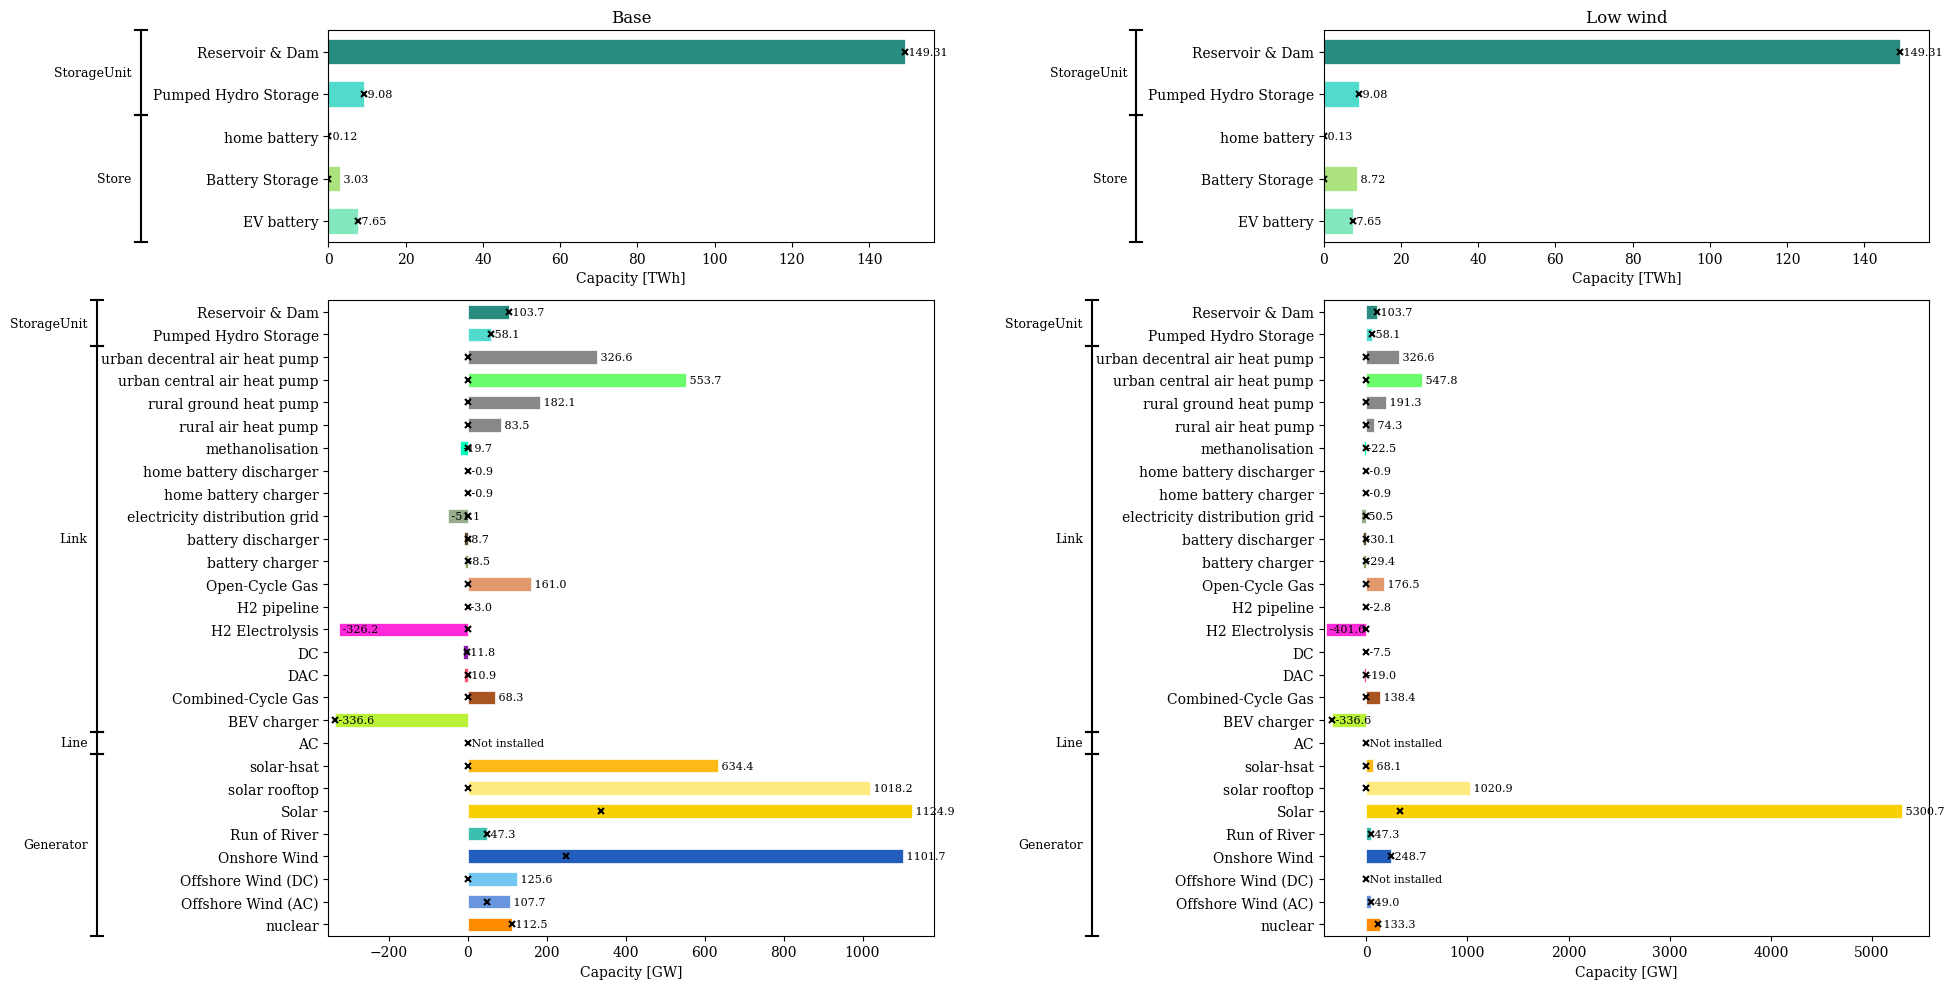

In [35]:
runs = [sample_base_2h_irena_phs, sample_low_wind]
elec_carriers = [
    "AC",
    "DC",
    "Battery Storage",
    "home battery",
    "low voltage",
    "EV battery",
    "Battery Storage",
    "battery",
]

fig, ax = plt.subplots(
    2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]}
)

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(
        drop_zero=False,
        nice_names=False,
        round=3,
        groupby="carrier",
        storage=True,
        bus_carrier=elec_carriers,
    )
    opt = stats[run].optimal_capacity(
        drop_zero=False,
        nice_names=False,
        round=3,
        groupby="carrier",
        storage=True,
        bus_carrier=elec_carriers,
    )
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = (
        stats[run]
        .installed_capacity(
            drop_zero=False,
            nice_names=False,
            round=3,
            groupby="carrier",
            bus_carrier=elec_carriers,
        )
        .drop("Store")
    )
    opt = (
        stats[run]
        .optimal_capacity(
            drop_zero=False,
            nice_names=False,
            round=3,
            groupby="carrier",
            bus_carrier=elec_carriers,
        )
        .drop("Store")
    )
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

### Elec generation by scenario

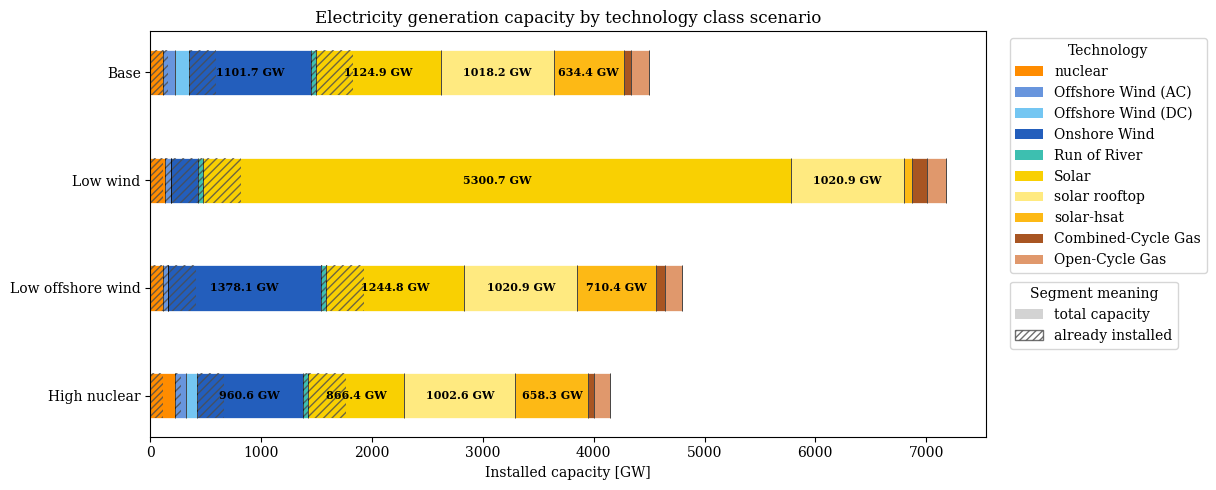

In [36]:
# Example usage
# runs = [sample_base_2h_irena_phs, sample_high_nuclear, sample_low_wind, sample_low_offwind]
runs = [
    sample_high_nuclear,
    sample_low_offwind,
    sample_low_wind,
    sample_base_2h_irena_phs,
]
elec_carriers = [
    "AC",
    "DC",
    "Battery Storage",
    "home battery",
    "low voltage",
    "EV battery",
    "battery",
]

cap_bounds = build_capacity_bounds_df(
    stats,
    runs,
    storage=False,
    bus_carrier=elec_carriers,
    scale=1e3,  # MW -> GW
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_stacked_capacity(
    cap_bounds,
    ax,
    scenarios=runs,
    generation_only=True,
    p_nom_col="p_nom",
    p_nom_min_col="p_nom_min",
    title="Electricity generation capacity by technology class scenario",
)
fig.tight_layout()
plt.show()

### Storage by scenario

/Users/jopeel/Documents/Code/Development/materials/pypsa-eur-aysha/analysis/mineral_analysis_lib.py:2311: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



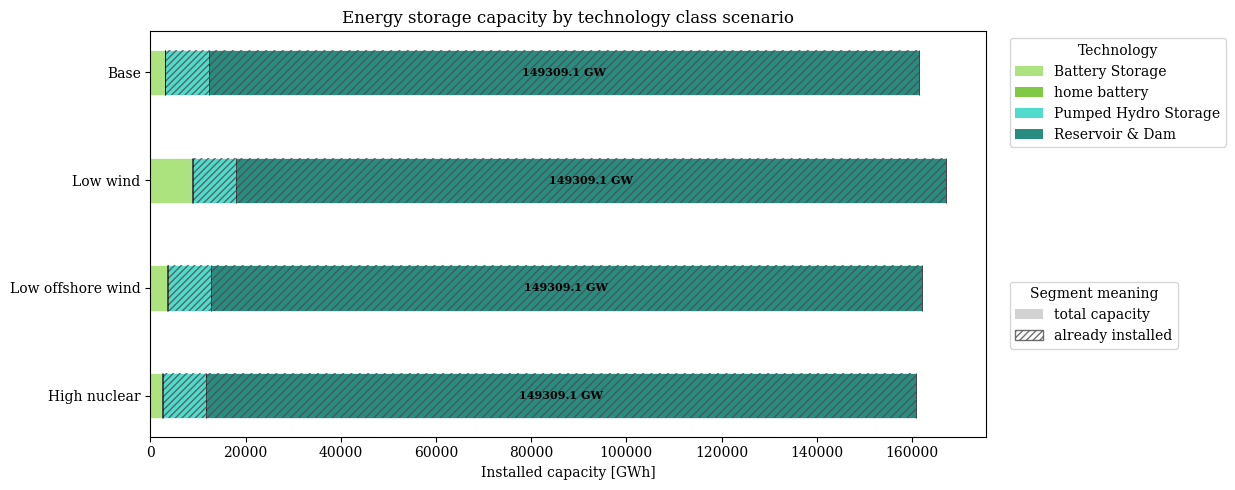

In [37]:
cap_bounds = build_capacity_bounds_df(
    stats,
    runs,
    storage=True,
    bus_carrier=elec_carriers,
    scale=1e3,  # MW -> GW
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_stacked_capacity(
    cap_bounds,
    ax,
    scenarios=runs,
    storage_only=True,
    p_nom_col="p_nom",
    p_nom_min_col="p_nom_min",
    title="Energy storage capacity by technology class scenario",
)
fig.tight_layout()
plt.show()

## Yearly energy generation

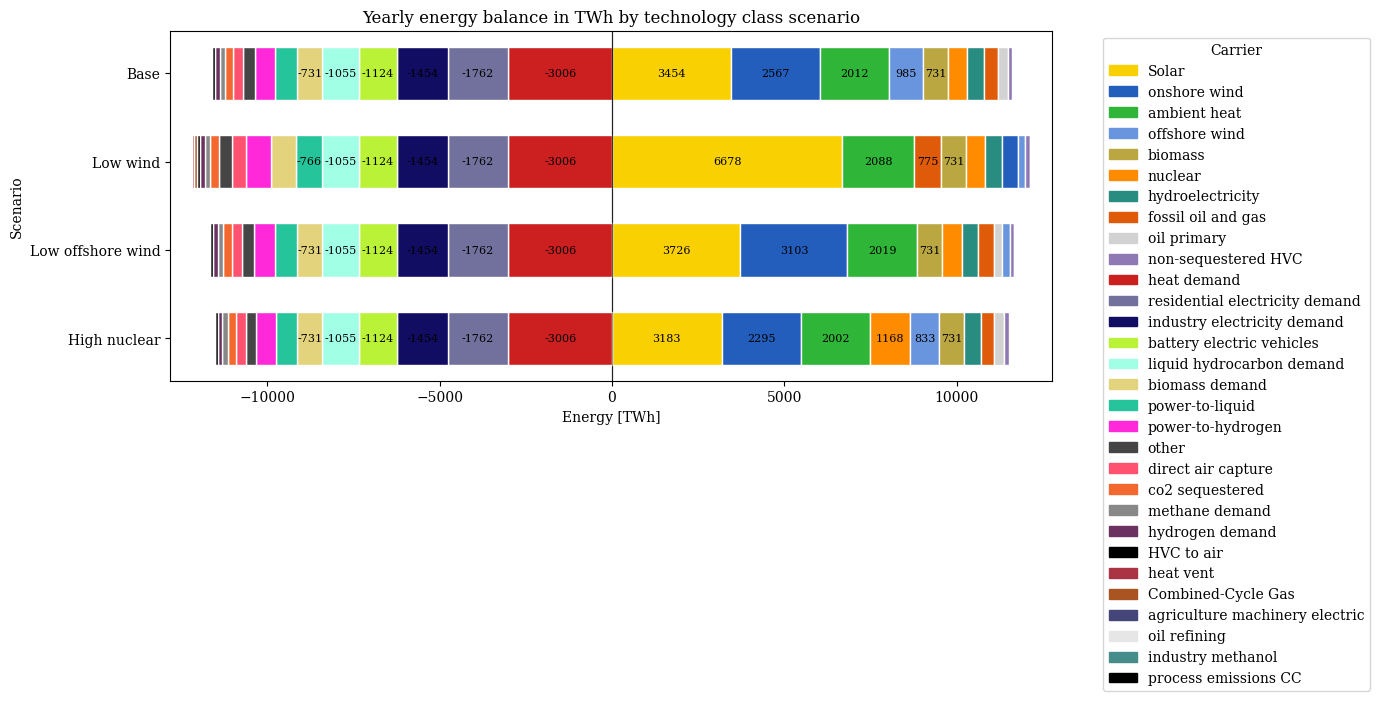

In [38]:
runs = [
    sample_base_2h_irena_phs,
    sample_low_wind,
    sample_low_offwind,
    sample_high_nuclear,
]

series_by_run = {}
carriers_to_exclude = ["co2", "co2 stored", "process emissions"]

for run in runs:
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3)
    eb_filtered = (
        eb[~eb.index.get_level_values(1).isin(carriers_to_exclude)]
        .groupby(["component", "carrier"])
        .sum()
    )
    comp = eb_filtered.index.get_level_values(0)
    carrier_renamed = eb_filtered.index.get_level_values(1).map(rename_techs_balances)
    eb_tyndp = eb_filtered.groupby([carrier_renamed]).sum()
    # eb_tyndp.index = eb_tyndp.index.set_names(eb_filtered.index.names)
    series_by_run[run] = eb_tyndp / 1e6  # TWh

# rows=scenarios, columns=(component, carrier)
plot_df = pd.DataFrame(series_by_run).T.fillna(0.0)

fig, ax = plt.subplots(figsize=(14, 1 * len(plot_df) + 2))
stacked_barh_signed(
    plot_df,
    ax,
    annotate_thresh=0.06,
    annotate_decimals=0,
)
ax.set_xlabel("Energy [TWh]")
plt.title("Yearly energy balance in TWh by technology class scenario")
plt.tight_layout()
plt.show()

## Mineral use

Compare overall mineral usage

### Mineral flow sankeys

In [39]:
network_key = sample_base_2h_irena_phs
df_merged, totals_Mt = compute_mineral_demand_network(
    n[network_key],
    all_minerals,
    "Market share current",
    mineral_intensities,
    tech_scenarios,
    capacity_col_name="capacity",
    evs=True,
)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    all_minerals,
    tech_col="carrier_renamed",
    network_name=network_key,
    mode="mass",
    # criticality_df=criticality,
    criticality_min_col=None,  # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3,
    min_tech_share=0.05,
    title="a) Cumulative metal to technology flows in the base scenario",
)

In [40]:
network_key = sample_base_2h_irena_phs

df_merged, totals_Mt = compute_mineral_demand_network(
    n[network_key],
    rare_earths,
    "Market share current",
    mineral_intensities,
    tech_scenarios,
    capacity_col_name="capacity",
    evs=True,
)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    rare_earths,
    tech_col="carrier_renamed",
    network_name=network_key,
    mode="mass",
    # criticality_df=criticality,
    criticality_min_col=None,  # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3,
    min_tech_share=0.05,
    title="b) Cumulative rare earth to technology flows in the base scenario",
)

In [41]:
network_key = sample_low_wind
df_merged, totals_Mt = compute_mineral_demand_network(
    n[network_key],
    all_minerals,
    "Market share current",
    mineral_intensities,
    tech_scenarios,
    capacity_col_name="capacity",
    evs=True,
)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    ["Indium", "Gallium"],
    tech_col=None,
    network_name=network_key,
    mode="mass",
    # criticality_df=criticality,
    criticality_min_col=None,  # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3,
    min_tech_share=0.05,
)

In [42]:
network_key = sample_low_wind
df_merged, totals_Mt = compute_mineral_demand_network(
    n[network_key],
    all_minerals,
    "Market share current",
    mineral_intensities,
    tech_scenarios,
    capacity_col_name="capacity",
    evs=True,
)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    all_minerals,
    tech_col=None,
    network_name=network_key,
    mode="mass",
    # criticality_df=criticality,
    criticality_min_col=None,  # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3,
)

To do: 
- Try criticality scores with different countries to validate scores. 


- Note: for supply comparison, we are comparing *yearly* supply (from IEA) to total cumulative demand from energy system until 2050

### Mineral use vs reserves

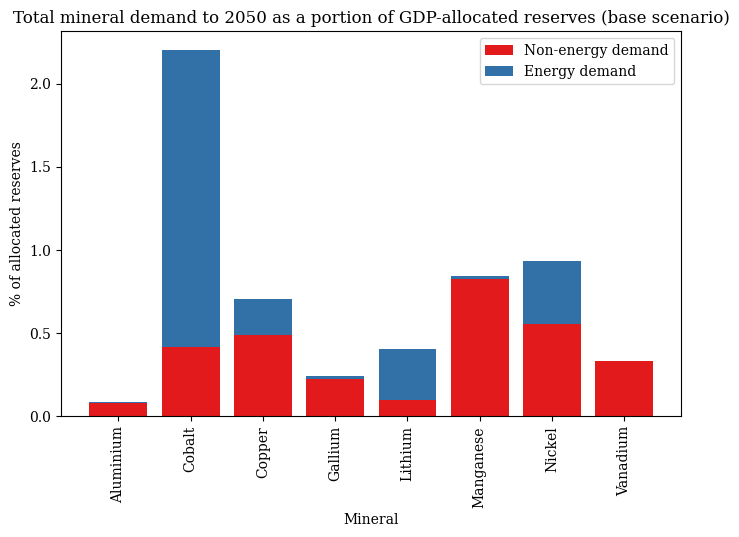

In [43]:
# now compare total demand to reserves
network_key = sample_base_2h_irena_phs

df_merged, totals_Mt = compute_mineral_demand_network(
    n[network_key],
    all_minerals,
    "Market share current",
    mineral_intensities,
    tech_scenarios,
    capacity_col_name="capacity",
    evs=True,
)
totals_Mt.loc["REE"] = totals_Mt.loc[["Praseodymium", "Neodymium", "Dysprosium"]].sum()
demand_df = totals_Mt.reset_index()
demand_df.columns = ["Mineral", "Demand (Mt)"]

non_energy_demand_cumulative = non_energy_demand[
    non_energy_demand["Year"] == "Cumulative"
][["Mineral", "GDP-adjusted value entso-e (Mt)"]]


reserves = mineral_avail[mineral_avail["Estimate method"] == "Reserves"]

# Merge reserves with energy demand and non-energy demand
merged = pd.merge(reserves, demand_df, on="Mineral", how="outer")
merged = pd.merge(merged, non_energy_demand_cumulative, on="Mineral", how="inner")


merged.rename(
    columns={"GDP-adjusted value entso-e (Mt)": "Non-energy demand (Mt)"}, inplace=True
)
merged["GDP-allocated reserves"] = (
    merged["Value (Mt)"] * mineral_alloc_factors["GDP share"]
)

merged["Eur transition demand per total reserves"] = (
    merged["Demand (Mt)"] / merged["Value (Mt)"]
)
merged["Eur transition demand per total allocated reserves"] = (
    merged["Demand (Mt)"] / merged["GDP-allocated reserves"]
)

merged["Eur other demand per total reserves"] = (
    merged["Non-energy demand (Mt)"] / merged["Value (Mt)"]
)
merged["Eur other demand per total allocated reserves"] = (
    merged["Non-energy demand (Mt)"] / merged["GDP-allocated reserves"]
)

fig, ax = plt.subplots(figsize=(8, 5))

to_plot = merged[(~merged["Value (Mt)"].isna()) & (~merged["Demand (Mt)"].isna())]
# to_plot

ax.bar(
    to_plot["Mineral"],
    to_plot["Eur other demand per total allocated reserves"],
    color="#e31a1c",
    label="Non-energy demand",
)
ax.bar(
    to_plot["Mineral"],
    to_plot["Eur transition demand per total allocated reserves"],
    bottom=to_plot["Eur other demand per total allocated reserves"],
    color="#3271a8",
    label="Energy demand",
)

ax.set_ylabel("% of allocated reserves")
ax.set_xlabel("Mineral")

plt.xticks(rotation=90)
plt.title(
    "Total mineral demand to 2050 as a portion of GDP-allocated reserves (base scenario)"
)
plt.legend(loc="upper right")

plt.show()

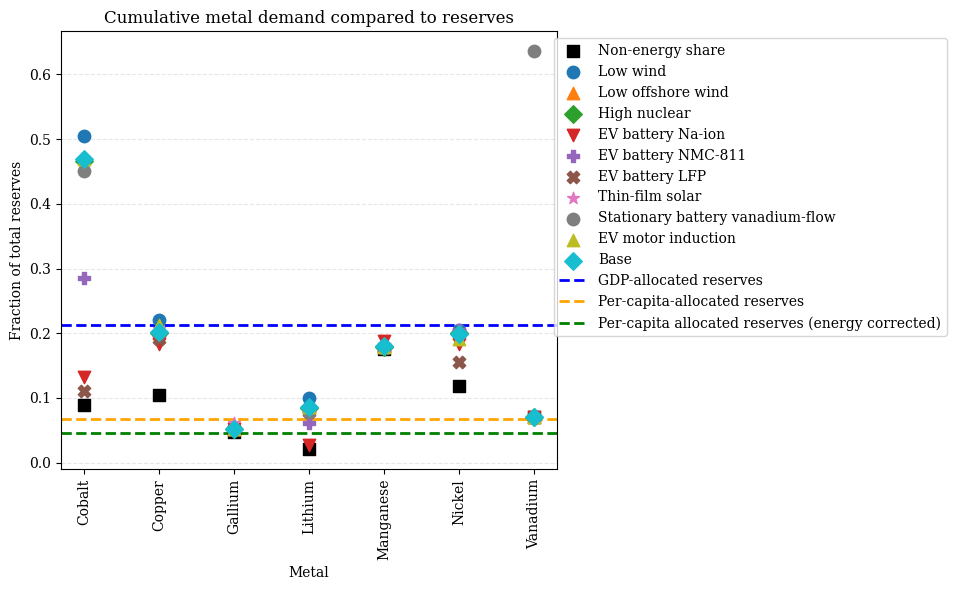

In [44]:
# Example usage (matches the stacked bar chart example above):
# Guarded so this cell can be run even if the example scenarios are not defined yet.

scenario_defs = [
    (sample_low_wind, sample_low_wind, "Market share current"),
    (sample_low_offwind, sample_low_offwind, "Market share current"),
    (sample_high_nuclear, sample_high_nuclear, "Market share current"),
    ("EV battery Na-ion", sample_base_2h_irena_phs, "EV battery Na-ion"),
    ("EV battery NMC-811", sample_base_2h_irena_phs, "EV battery NMC-811"),
    ("EV battery LFP", sample_base_2h_irena_phs, "EV battery LFP"),
    ("Thin-film solar", sample_base_2h_irena_phs, "Thin-film solar"),
    (
        "Stationary battery vanadium-flow",
        sample_base_2h_irena_phs,
        "Stationary battery vanadium-flow",
    ),
    ("EV motor induction", sample_base_2h_irena_phs, "EV motor induction"),
    (sample_base_2h_irena_phs, sample_base_2h_irena_phs, "Market share current"),
]


battery_minerals = [
    "Cobalt",
    "Copper",
    "Gallium",
    "Graphite",
    "Lithium",
    "Manganese",
    "Nickel",
    "Vanadium",
]
# battery_minerals = ["Lithium", "Graphite","Cobalt", "Manganese", "Nickel",  "Vanadium", "Gallium", "Neodymium", "Dysprosium", "Tellurium", "REE"]

test = plot_mineral_reserve_shares(
    scenario_defs,
    n,
    battery_minerals,
    mineral_intensities,
    tech_scenarios,
    non_energy_demand,
    grid_demand,
    mineral_avail,
    mineral_alloc_factors,
    title="Cumulative metal demand compared to reserves",
)

test.to_csv("reserves_plot_data.csv")

###  Mineral Supply

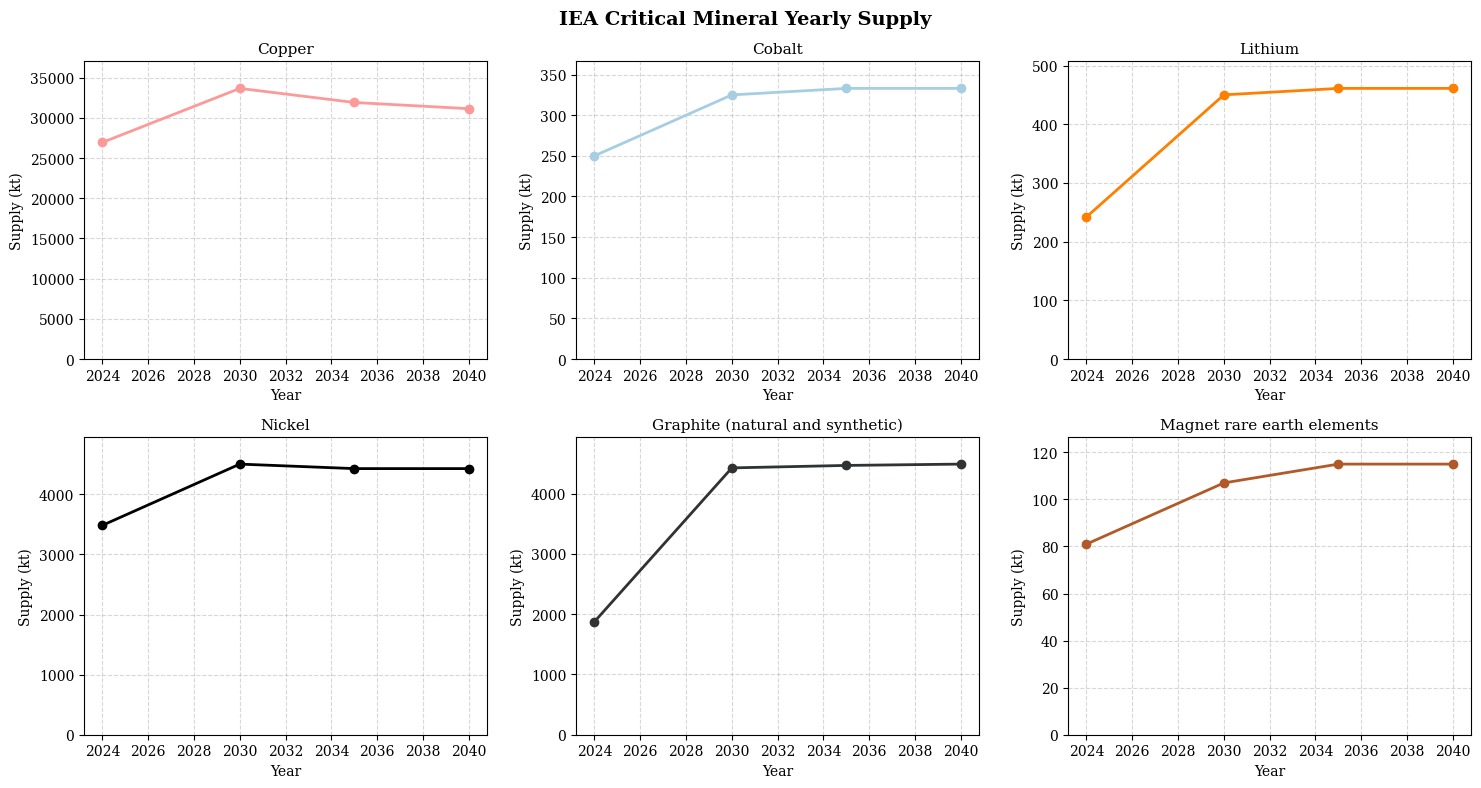

In [45]:
iea_supply_yearly = pd.read_csv("data/IEA_cm_yearly_avail.csv")
extrapolated_supply_yearly = pd.read_csv("data/extrapolated supply.csv")

iea_supply_yearly.columns = iea_supply_yearly.columns.str.strip()
minerals_in_df = [
    c for c in iea_supply_yearly.columns if c != "Year" and not c.startswith("Unnamed")
]

# Fallback overrides for column names that may differ from minerals_color_map keys
_color_overrides = {
    "Magnet rare earth elements": minerals_color_map.get(
        "Magnet rare earth elements", minerals_color_map.get("REE", "#b15928")
    ),
    "Graphite": minerals_color_map.get(
        "Graphite",
        minerals_color_map.get("Graphite (natural and synthetic)", "#303234"),
    ),
}


def _get_color(mineral):
    return minerals_color_map.get(mineral) or _color_overrides.get(mineral, "#888888")


n_minerals = len(minerals_in_df)
ncols = 3
nrows = (n_minerals + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

# years_with_data=[2024, 2030, 2035, 2040]

for i, mineral in enumerate(minerals_in_df):
    ax = axes[i]
    ax.plot(
        iea_supply_yearly["Year"],
        iea_supply_yearly[mineral],
        color=_get_color(mineral),
        linewidth=2,
        marker="o",
    )
    ax.set_title(mineral, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Supply (kt)")
    # ax.set_xticks(years_with_data)
    ax.set_ylim(bottom=0, top=iea_supply_yearly[mineral].max() * 1.1)
    ax.grid(True, linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("IEA Critical Mineral Yearly Supply", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

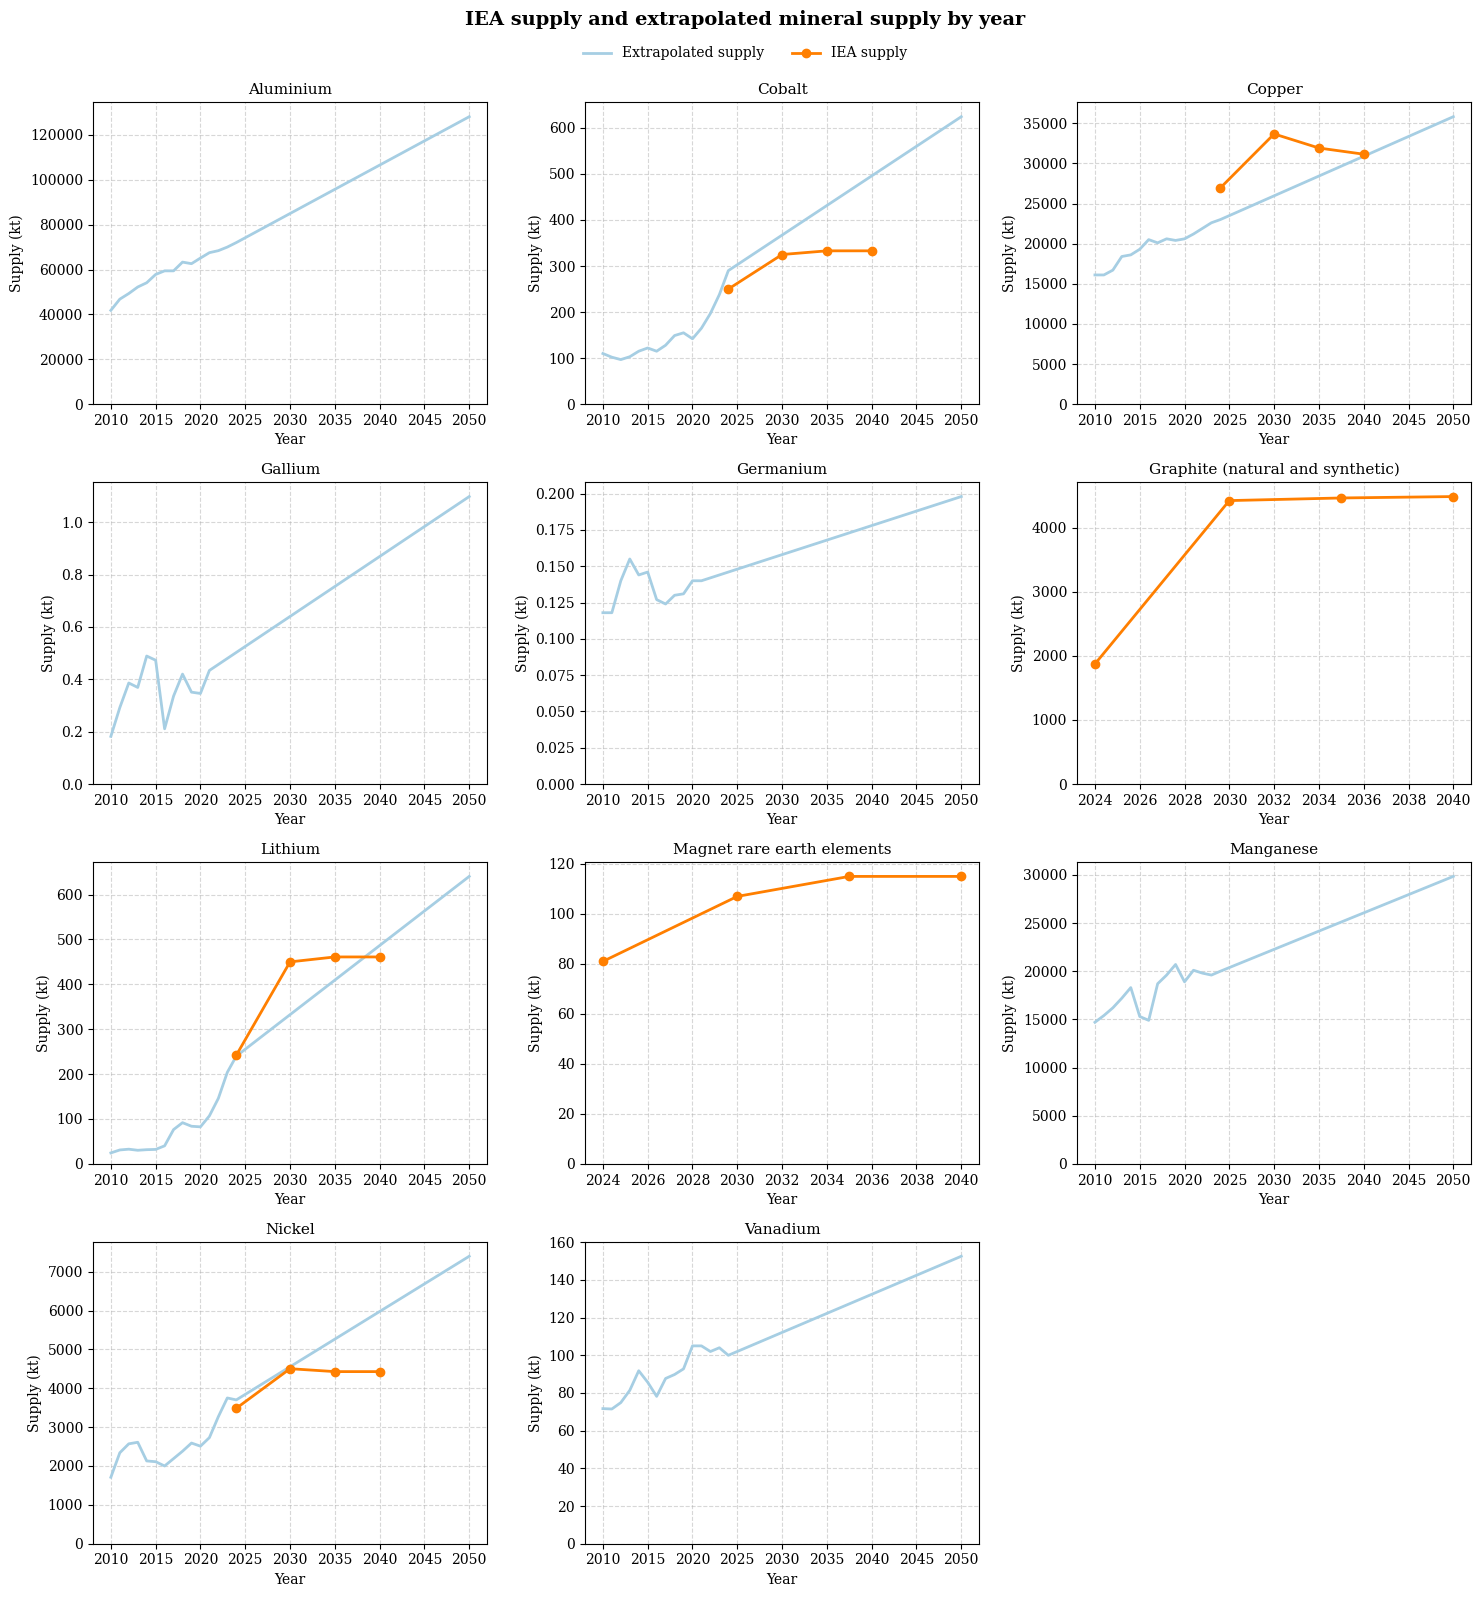

In [46]:
extrapolated_supply_yearly = pd.read_csv("data/extrapolated supply.csv")
iea_supply_yearly = pd.read_csv("data/IEA_cm_yearly_avail.csv")

minerals_in_df = sorted(
    c
    for c in set(extrapolated_supply_yearly.columns) | set(iea_supply_yearly.columns)
    if c != "Year" and not c.startswith("Unnamed")
)


def _get_color(mineral):
    return minerals_color_map.get(mineral) or _color_overrides.get(mineral, "#888888")


n_minerals = len(minerals_in_df)
ncols = 3
nrows = (n_minerals + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

# years_with_data=[2024, 2030, 2035, 2040]

for i, mineral in enumerate(minerals_in_df):
    ax = axes[i]
    y_max_candidates = []

    if mineral in extrapolated_supply_yearly.columns:
        y1 = extrapolated_supply_yearly[mineral]
        ax.plot(extrapolated_supply_yearly["Year"], y1, color="#a6cee3", linewidth=2)
        y_max_candidates.append(y1.max())

    if mineral in iea_supply_yearly.columns:
        y2 = iea_supply_yearly[mineral]
        ax.plot(iea_supply_yearly["Year"], y2, color="#ff7f00", linewidth=2, marker="o")
        y_max_candidates.append(y2.max())

    # y-axis from 0 to (max plotted value + 5%)
    if y_max_candidates:
        y_max = max(y_max_candidates)
        ax.set_ylim(0, y_max * 1.05)

    ax.set_title(mineral, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Supply (kt)")
    ax.set_ylim(bottom=0)
    # ax.set_xticks(years_with_data)
    # ax.set_ylim(bottom=0, top=extrapolated_supply_yearly[mineral].max() * 1.1)
    ax.grid(True, linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    Line2D([0], [0], color="#a6cee3", lw=2, label="Extrapolated supply"),
    Line2D([0], [0], color="#ff7f00", lw=2, marker="o", label="IEA supply"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.980),
)

fig.suptitle(
    "IEA supply and extrapolated mineral supply by year",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
# Reserve top for suptitle and bottom for legend
plt.tight_layout(rect=[0, 0, 1, 0.98])

### Cumulative mineral use

In [47]:
# Example: one figure with minerals drawing from different non-energy and availability datasets
base_scenario = sample_base_2h_irena_phs
network_scenarios = [
    sample_base_2h_irena_phs,
    sample_low_wind,
    sample_low_offwind,
    sample_high_nuclear,
]
market_scenarios = [
    "EV battery Na-ion",
    "EV battery NMC-811",
    "EV battery LFP",
    "Thin-film solar",
    "Stationary battery vanadium-flow",
    "EV motor induction",
]

In [48]:
# cobalt overuse
print((4.19380179 + 0.97210767) / 1.8346392399449998)

# nickel overuse:
print((15.38434922 + 10.50035203) / 24.617689704)

# graphite
print((34.22322248 + 16.49083768) / 24.7623029016)

# manganese
print((298.48851851 + 6.70524296) / 139.0631357082)

# vanadium
print((1.26726141) / 0.704928064377)

# cobalt use from EVs
print(3.975521 / (0.97210767 + 4.19380179))

# lithium use from EVs
print(1.748298 / (0.61657894 + 1.96683515))

2.815763092560294
1.051467524419813
2.048034884377541
2.1946417353222674
1.797717347400515
0.7695684623942287
0.6767393608200069


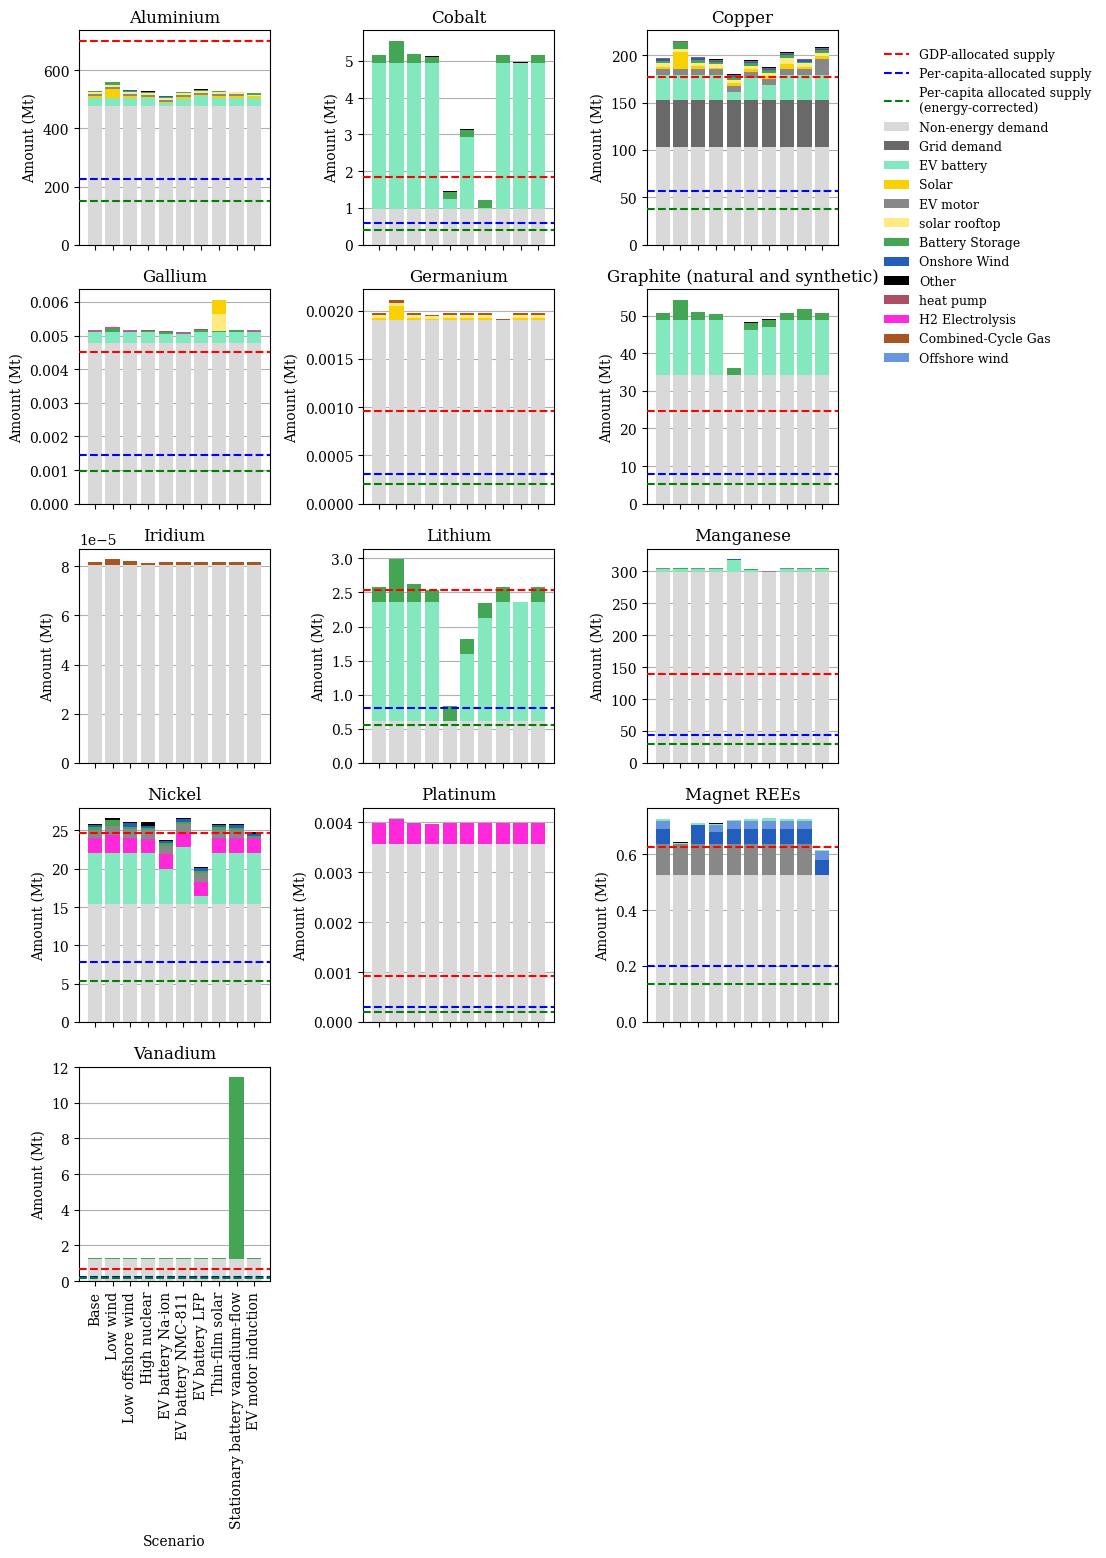

In [49]:
demand_df = compute_mineral_demand_scenarios(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs,
    mineral_intensities=mineral_intensities,
    tech_scenarios=tech_scenarios,
    non_energy_demand=non_energy_demand,
    grid_demand=grid_demand,
    non_energy_col="GDP-adjusted value entso-e (Mt)",
    tech_group_col="carrier_renamed",
    min_tech_share=0.01,
)
supply_df = compute_mineral_supply(
    mineral_specs,
    mineral_avail=mineral_avail,
    mineral_alloc_factors=mineral_alloc_factors,
)
plot_mineral_scenario_comparison(
    demand_df,
    supply_df,
)

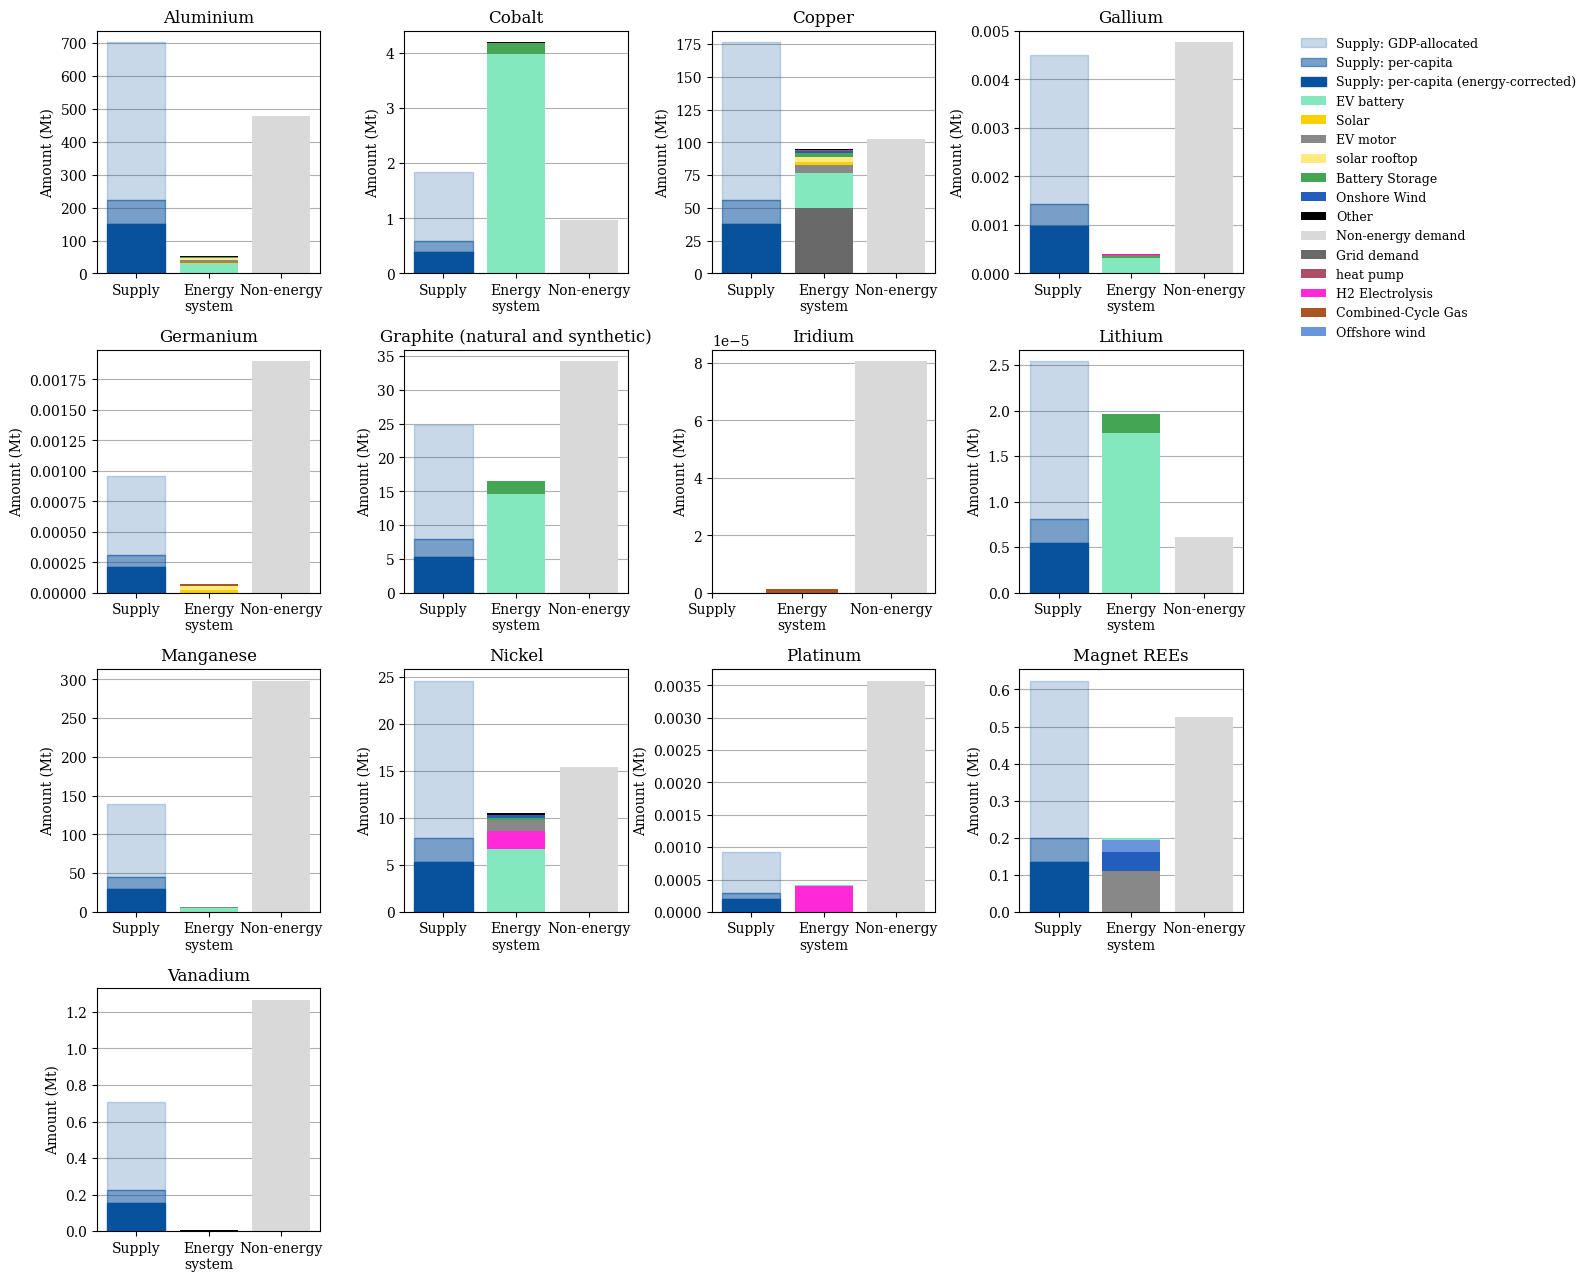

In [50]:
plot_mineral_supply_demand(
    demand_df,
    supply_df,
    ncols=4,
    figwidth=19,
)

### Supply-deficit summary table

Per material: which allocation-based supply level the base-scenario energy demand, non-energy demand (NED) and total demand exceed; the energy/NED ratio; and which scenarios reduce the material's total demand.


In [51]:
deficit_table = build_supply_deficit_table(demand_df, supply_df, base_scenario)
deficit_table

,Energy demand outcome,Non-energy demand outcome,Total demand outcome,Outcome after optimisation,Energy/NED ratio,Demand-reducing scenarios
Material,,,,,,
Aluminium,Within supply,Exceeds per-capita supply,Exceeds per-capita supply,Exceeds per-capita supply,0.108048,"EV battery NMC-811, EV battery Na-ion, EV moto..."
Cobalt,Exceeds GDP supply,Exceeds per-capita supply,Exceeds GDP supply,Exceeds per-capita supply,4.314133,"EV battery LFP, EV battery NMC-811, EV battery..."
Copper,Exceeds per-capita supply,Exceeds per-capita supply,Exceeds GDP supply,Exceeds GDP supply,0.924064,"EV battery LFP, EV battery NMC-811, EV battery..."
Gallium,Within supply,Exceeds GDP supply,Exceeds GDP supply,Exceeds GDP supply,0.082787,"EV battery NMC-811, EV battery Na-ion"
Germanium,Within supply,Exceeds GDP supply,Exceeds GDP supply,Exceeds GDP supply,0.037672,"EV battery LFP, EV battery NMC-811, EV battery..."
Graphite (natural and synthetic),Exceeds per-capita supply,Exceeds GDP supply,Exceeds GDP supply,Exceeds GDP supply,0.481861,"EV battery LFP, EV battery NMC-811, EV battery..."
Iridium,No supply data,No supply data,No supply data,No supply data,0.015421,"EV battery NMC-811, EV battery Na-ion, High nu..."
Lithium,Exceeds per-capita supply,Exceeds per-capita supply (energy-corrected),Exceeds GDP supply,Exceeds per-capita supply,3.189916,"EV battery LFP, EV battery NMC-811, EV battery..."
Magnet REEs,Exceeds per-capita supply,Exceeds per-capita supply,Exceeds GDP supply,Exceeds per-capita supply,0.381517,"EV battery NMC-811, EV battery Na-ion, EV moto..."


## Costs

(<Axes: title={'center': 'System cost breakdown by technology class scenario, billion Euros'}, ylabel='System cost (billion Euros)'>,
                                         Base   High nuclear  \
 carrier                                                       
 solar                          145842.545426  132510.813841   
 nuclear                        121739.034172  245154.902307   
 heat pumps                     136371.753204  136430.600964   
 onshore wind                   150540.489085  131266.278270   
 hydroelectricity                56062.072803   56061.981592   
 power-to-hydrogen               51614.554215   49469.108101   
 electricity distribution grid   54072.964573   54133.659689   
 battery storage                 31775.714467   25627.967970   
 offshore wind                   69347.397300   56849.925955   
 transmission lines              36007.359685   32318.219710   
 power-to-liquid                 25928.521155   24822.553401   
 carbon capture                  2

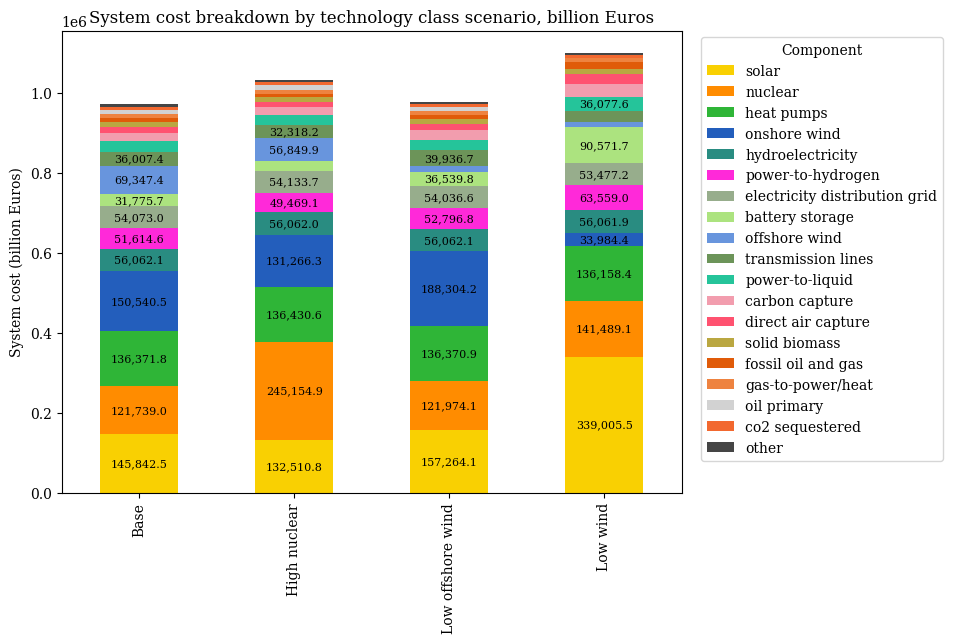

In [52]:
plot_system_cost_compare(
    n,
    [
        sample_base_2h_irena_phs,
        sample_high_nuclear,
        sample_low_offwind,
        sample_low_wind,
    ],
    cost_divisor=1e6,
    figsize=(8, 6),
    sort_components=True,
    annotate_thresh=0.03,
)

(<Axes: title={'center': 'System cost breakdown by technology class scenario, billion Euros'}, ylabel='System cost (billion Euros)'>,
                                      Base    Low wind  Low offshore wind  \
 carrier                                                                    
 solar                          127.413962  320.576901         138.835497   
 heat pumps                     136.371753  136.158425         136.370930   
 onshore wind                   116.567910    0.011811         154.331574   
 power-to-hydrogen               51.614554   63.559030          52.796801   
 electricity distribution grid   54.072965   53.477182          54.036638   
 nuclear                         15.120888   34.871002          15.355952   
 battery storage                 31.775714   90.571658          36.539847   
 power-to-liquid                 25.928521   36.077615          26.708412   
 offshore wind                   55.844813    0.005048           0.005258   
 carbon capture    

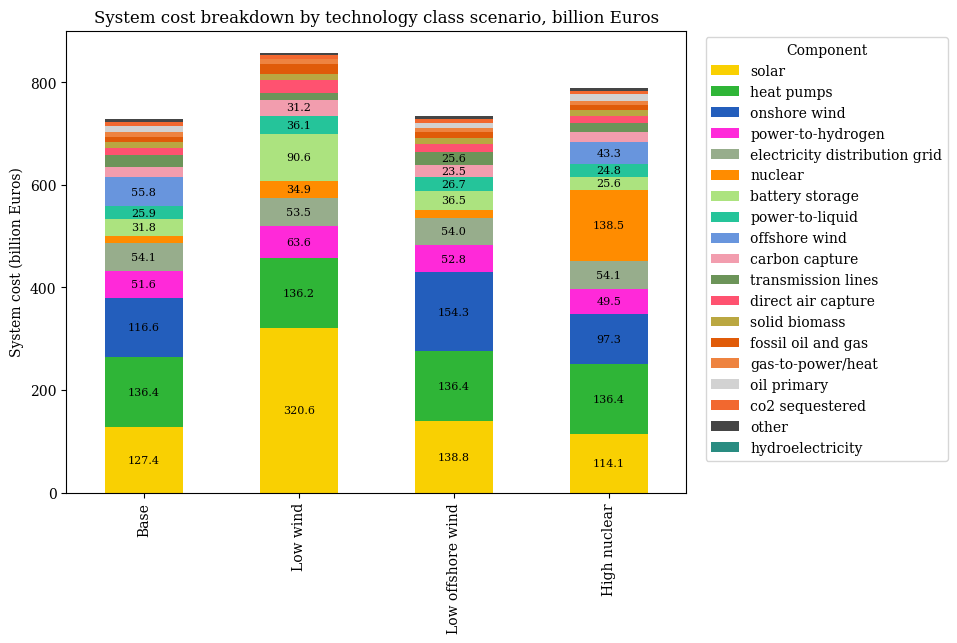

In [53]:
plot_system_cost_compare(
    n,
    [
        sample_base_2h_irena_phs,
        sample_low_wind,
        sample_low_offwind,
        sample_high_nuclear,
        sample_low_offwind,
        sample_low_wind,
    ],
    method="expanded",
    cost_divisor=1e9,
    figsize=(8, 6),
    sort_components=True,
    annotate_thresh=0.03,
)

# Paper

### Fig 1. The base scenario is a problem

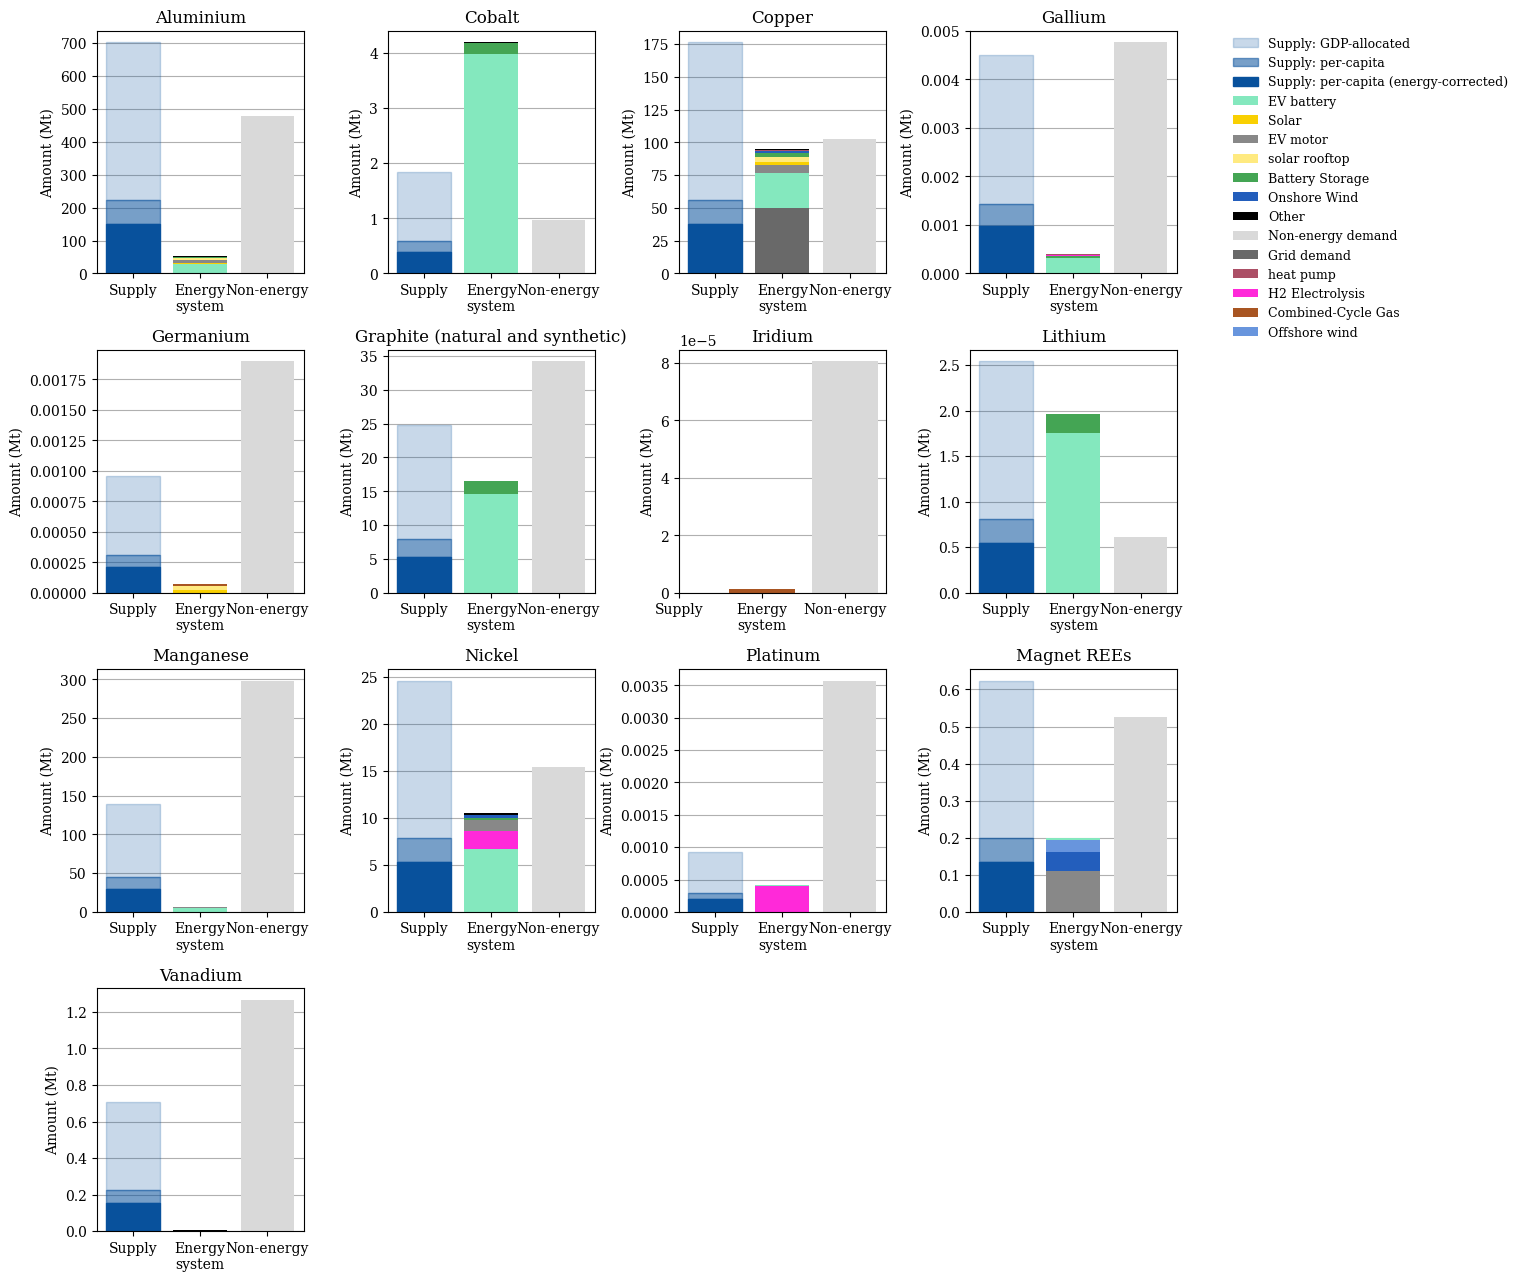

In [54]:
from mineral_analysis_lib import plot_mineral_supply_demand

plot_mineral_supply_demand(
    demand_df,
    supply_df,
    ncols=4,
    figwidth=18
)

### Fig 2. Mitigation scenarios help, but not enough

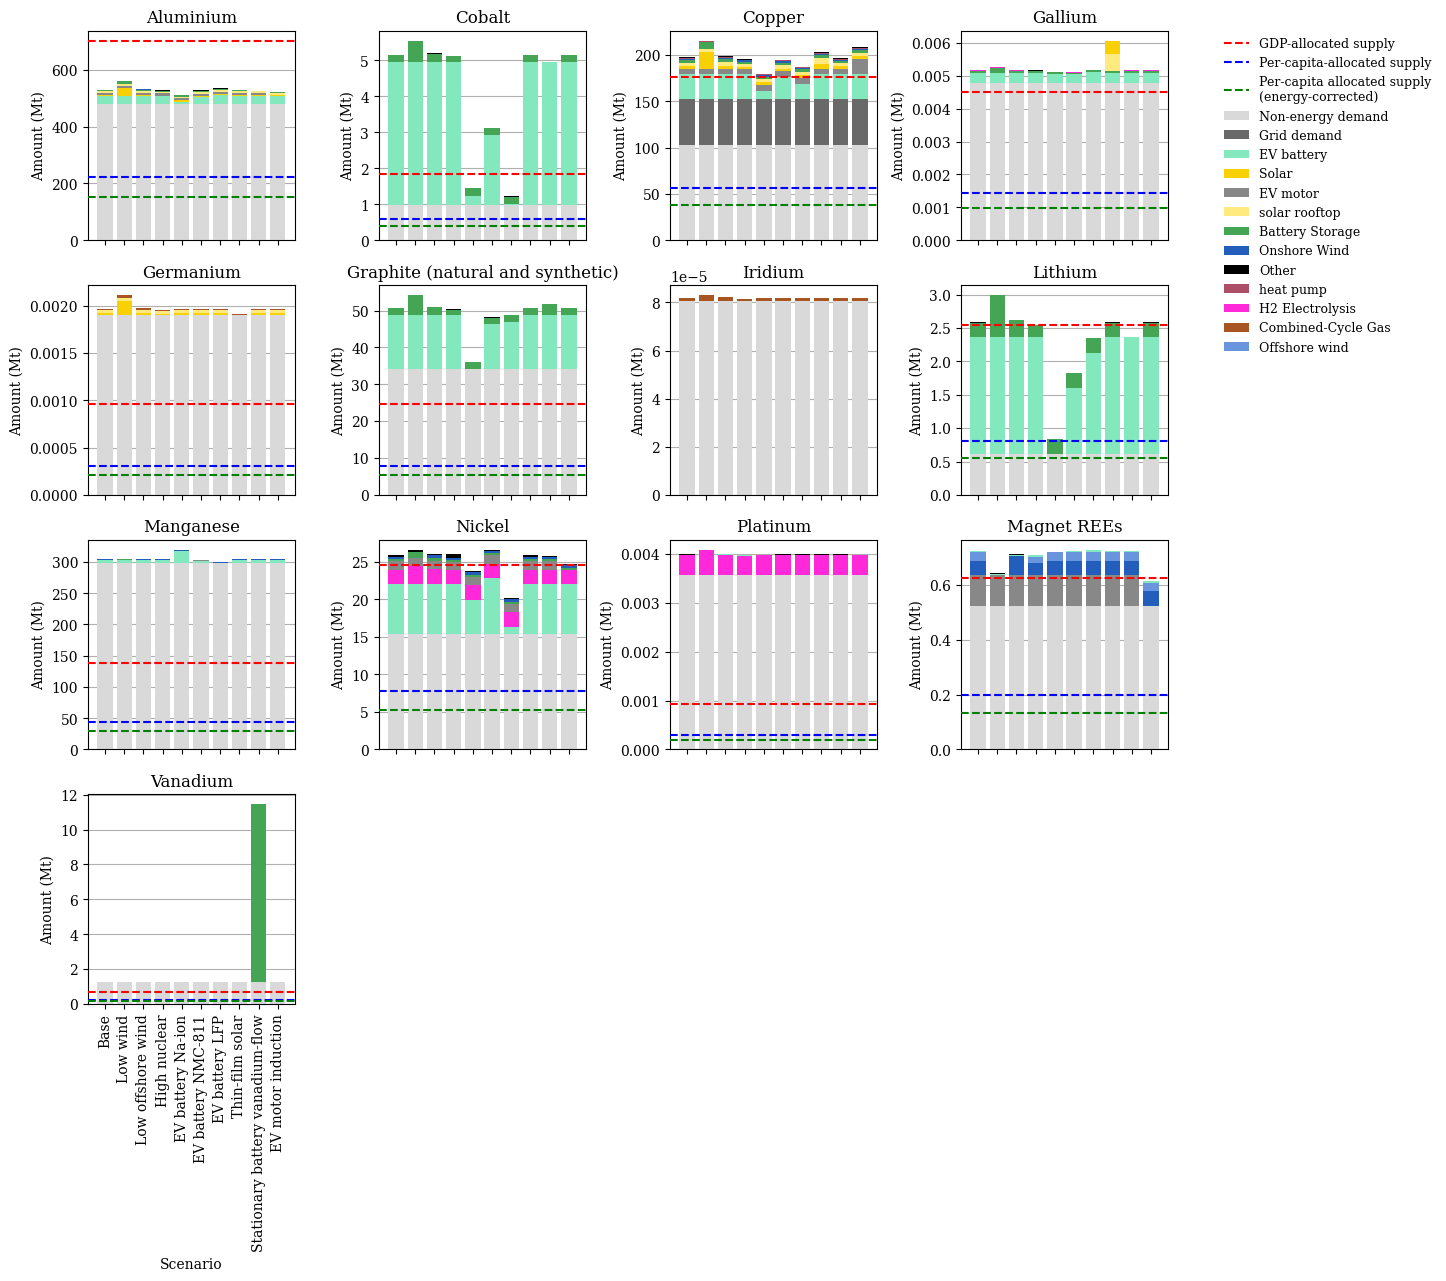

In [55]:
plot_mineral_scenario_comparison(
    demand_df,
    supply_df,
    ncols=4,
    figwidth=18
)

### Fig 3. Levers can reduce mineral demand

In [61]:
demand_df.head(100)

,Material,Scenario,Component,Value (Mt)
0,Aluminium,Base,Non-energy demand,478.153984
1,Aluminium,Base,Grid demand,0.000000
2,Aluminium,Low wind,Non-energy demand,478.153984
3,Aluminium,Low wind,Grid demand,0.000000
4,Aluminium,Low offshore wind,Non-energy demand,478.153984
5,Aluminium,Low offshore wind,Grid demand,0.000000
6,Aluminium,High nuclear,Non-energy demand,478.153984
7,Aluminium,High nuclear,Grid demand,0.000000
8,Aluminium,EV battery Na-ion,Non-energy demand,478.153984
9,Aluminium,EV battery Na-ion,Grid demand,0.000000
